ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](https://github.com/jeej11200-create/ARTI406-Assignment-2/blob/main/img/step2.png?raw=1)

In this lab, we will apply practical preprocessing techniques step by step.

In [62]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [63]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("ecommerce_user_behavior_8000 (1).csv")
df.head(10)

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0
5,6.0,56.0,Female,Desktop,26.60,1.0,12.0,7.0,1.0,1.0,0.0,28.40,13.90,1.0
6,7.0,36.0,Male,Mobile,7.60,11.0,11.0,6.0,1.0,1.0,1.0,4.51,13.12,1.0
7,8.0,40.0,Female,Mobile,26.98,7.0,5.0,2.0,1.0,0.0,0.0,33.34,12.61,1.0
8,9.0,28.0,Female,Mobile,10.90,14.0,7.0,9.0,0.0,0.0,1.0,13.80,85.46,1.0
9,10.0,28.0,Female,Mobile,9.97,3.0,14.0,8.0,0.0,0.0,0.0,14.12,14.16,1.0


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [64]:
df.dtypes

,0
user_id,float64
age,float64
gender,object
device_type,object
time_on_site,float64
pages_viewed,float64
previous_purchases,float64
cart_items,float64
discount_seen,float64
ad_clicked,float64


We checked the data types of all columns and found that they were appropriate for the dataset. No incorrect data types were detected, so no conversion was required.

The dataset contains 8,000 records and 14 features. Several columns contain missing values, as each column has 7,840 non-null entries instead of 8,000. Therefore, missing value handling is required before further preprocessing.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [65]:
df.info()

print("\nMissing Values: ")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             7840 non-null   float64
 1   age                 7840 non-null   float64
 2   gender              7840 non-null   object 
 3   device_type         7840 non-null   object 
 4   time_on_site        7840 non-null   float64
 5   pages_viewed        7840 non-null   float64
 6   previous_purchases  7840 non-null   float64
 7   cart_items          7840 non-null   float64
 8   discount_seen       7840 non-null   float64
 9   ad_clicked          7840 non-null   float64
 10  returning_user      7840 non-null   float64
 11  avg_session_time    7840 non-null   float64
 12  bounce_rate         7840 non-null   float64
 13  purchase            7840 non-null   float64
dtypes: float64(12), object(2)
memory usage: 875.1+ KB

Missing Values: 
user_id               160
age       

In [66]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [67]:
df.isna().sum()

,0
user_id,160
age,160
gender,160
device_type,160
time_on_site,160
pages_viewed,160
previous_purchases,160
cart_items,160
discount_seen,160
ad_clicked,160


The output shows that all columns contain 160 missing values. These missing values must be handled before applying further preprocessing techniques and machine learning algorithms.

# 3.2 Handling Missing Values

In [68]:
# Handle Missing Values using Median and Mode

num_cols = ['age','time_on_site','pages_viewed',
            'previous_purchases','cart_items',
            'discount_seen','ad_clicked',
            'returning_user','avg_session_time',
            'bounce_rate','purchase']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])
df['user_id'] = df['user_id'].fillna(df['user_id'].median())

print(df.isnull().sum())

user_id               0
age                   0
gender                0
device_type           0
time_on_site          0
pages_viewed          0
previous_purchases    0
cart_items            0
discount_seen         0
ad_clicked            0
returning_user        0
avg_session_time      0
bounce_rate           0
purchase              0
dtype: int64


Missing values were handled using median imputation for numerical features and mode imputation for categorical features. After preprocessing, no missing values remained in the dataset.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](https://github.com/jeej11200-create/ARTI406-Assignment-2/blob/main/img/IQR.png?raw=1)

### 4.1 Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [69]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['age'] < lower) | (df['age'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


Outliers were detected using the IQR method on the age feature. No outliers were found in the dataset, therefore no records were removed.

## 4.2 Boxplot Visualization

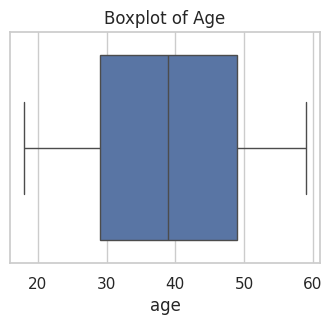

In [70]:
plt.figure(figsize=(4,3))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

The boxplot shows the distribution of the age feature. No outliers were observed outside the whiskers, indicating that the data does not contain extreme age values.

### 4.3 Remove Outliers
We remove values outside the acceptable range.

In [71]:
df_no_outliers = df[(df['age'] >= lower) & (df['age'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (8000, 14)
After removing outliers: (8000, 14)


No outliers were detected in the age feature using the IQR method. Therefore, the dataset size remained unchanged after the outlier removal process.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](https://github.com/jeej11200-create/ARTI406-Assignment-2/blob/main/img/min_max.png?raw=1)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

## Original Values Before Normalization

In [72]:
df[['age', 'time_on_site']].head()

,age,time_on_site
0,56.0,12.90
1,46.0,15.63
2,32.0,11.64
3,25.0,22.71
4,38.0,26.35


### Apply Min-Max Normalization

In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df[['age', 'time_on_site']].copy()

df_scaled[['age', 'time_on_site']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,age,time_on_site
0,0.926829,0.410345
1,0.682927,0.504483
2,0.341463,0.366897
3,0.170732,0.748621
4,0.487805,0.874138


After applying Min-Max normalization, the selected numerical features were scaled to a range between 0 and 1 while preserving the relative relationships between data points.

### 5.2 Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](https://github.com/jeej11200-create/ARTI406-Assignment-2/blob/main/img/zscore.png?raw=1)

This method keeps the shape of the distribution but rescales it around zero.

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df[['age', 'time_on_site']].copy()

df_standardized[['age', 'time_on_site']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,age,time_on_site
0,1.460343,-0.340072
1,0.620878,-0.010290
2,-0.554372,-0.492279
3,-1.141997,0.844970
4,-0.050693,1.284680


After applying Z-score normalization, the age and time_on_site features were standardized to have a mean close to 0 and a standard deviation close to 1. This transformation preserves the original distribution while placing features on a common scale.

## 5.3 Check Correlation Before Applying PCA

Correlation analysis was performed to examine the relationship between the numerical features before applying PCA. Highly correlated features may contain redundant information, making dimensionality reduction more effective.


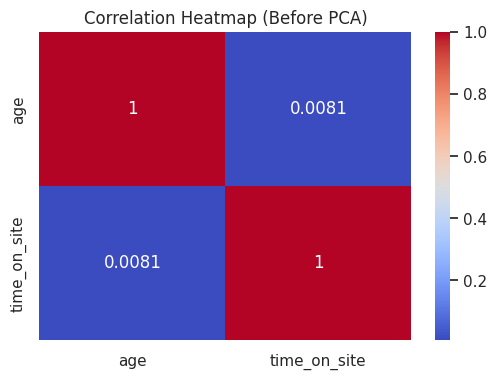

In [75]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df_standardized[['age','time_on_site']].corr(),
    annot=True,
    cmap="coolwarm" )

plt.title("Correlation Heatmap (Before PCA)")
plt.show()

The heatmap shows the correlation between the selected numerical features (age and time_on_site). The correlation value is approximately 0.008, which is very close to 0. This indicates that there is almost no linear relationship between the two features. Therefore, PCA is applied mainly for demonstration purposes, and the dimensionality reduction benefit may be limited.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) was applied to reduce dimensionality by transforming the original features into a smaller set of principal components while preserving as much information as possible.

In [76]:
from sklearn.decomposition import PCA

X = df_standardized[['age', 'time_on_site']]

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50406474 0.49593526]


The first principal component (PC1) explains approximately 50.41% of the total variance, while the second principal component (PC2) explains approximately 49.59%. Together, both components explain 100% of the variance in the selected features. This indicates that the information is distributed almost equally between the two components, and dimensionality reduction would provide limited benefit for these features.

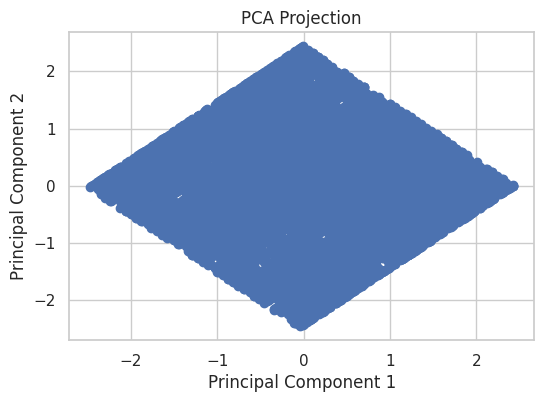

In [77]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The PCA projection visualizes the dataset in the new principal component space. Each point represents one user record after transformation. PC1 and PC2 capture the major variance present in the original features.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2